In [22]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import datasets, layers, models
import numpy as np

In [23]:
from tensorflow import keras
import os

if os.path.exists('cnn_model.h5'):
    model_loaded = keras.models.load_model('cnn_model.h5')
    print("Model loaded successfully")
else:
    print("cnn_model.h5 not found. You can train and save a model first.")

Model loaded successfully


In [24]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
# Fashion-MNIST is 28x28 grayscale. Resize to 32x32 and convert to RGB to match the model input.
import tensorflow as tf
# add channel dim
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]
# resize to 32x32
x_train = tf.image.resize(x_train, [32,32]).numpy()
x_test = tf.image.resize(x_test, [32,32]).numpy()
# convert to 3 channels (RGB) by repeating the single channel
x_train = np.repeat(x_train, 3, axis=-1)
x_test = np.repeat(x_test, 3, axis=-1)
# Convert to float16 first, then normalize to avoid excessive memory allocation
x_train = x_train.astype('float16')
x_train = x_train / 255.0
x_test = x_test.astype('float16')
x_test = x_test / 255.0

In [25]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)
print('x_train shape: ',x_train.shape)
print('x_train test: ',x_test.shape)

x_train shape:  (60000, 32, 32, 3)
x_train test:  (10000, 32, 32, 3)


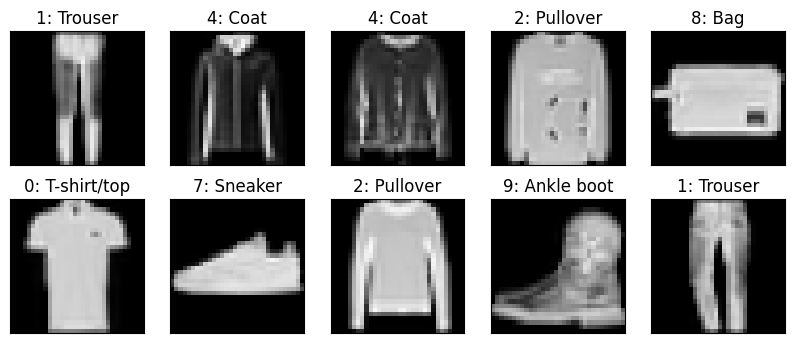

In [26]:
import matplotlib.pyplot as plt
import numpy as np
(_, _), (_, labels) = fashion_mnist.load_data()
idx = [3, 6, 25, 46, 58, 85, 93, 99, 108, 133]
clsmap = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot',
}
plt.figure(figsize = (10,4))
# Convert to float32 for display compatibility with matplotlib
x_test_display = x_test.astype('float32')
for i, (img, y) in enumerate(zip(x_test_display[idx].reshape(10,32,32,3), labels[idx])):
  plt.subplot(2,5,i+1)
  plt.imshow(img)
  plt.xticks([])
  plt.yticks([])
  plt.title(str(int(y)) + ": " + clsmap[int(y)])
plt.show()

In [27]:
model1 = models.Sequential()


In [28]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop

#dimensionality of input and latent encoded representations
inpt_dim = (32,32,3)
inpt_img= Input(shape=inpt_dim)
#Convolutional layer
c11 = Conv2D(64,(9,9), strides=(2,2), input_shape = inpt_dim, activation='relu')(inpt_img)
#Pooling and BatchNorm
p12 = MaxPooling2D(pool_size = (2,2))(c11)
bn13 = BatchNormalization()(p12)

# Add a second convolutional layer
c14 = Conv2D(128,(3,3), strides=(1,1), activation='relu')(bn13)
p15 = MaxPooling2D(pool_size = (2,2))(c14)
bn16 = BatchNormalization()(p15)

# Flattening for compatibility
f17 = Flatten()(bn16)
#Dense layers+ Dropout
do18 = Dropout(0.5)(f17)
d19 = Dense(units = 256,activation = 'relu')(do18)
do110 = Dropout(0.2)(d19)
d111 = Dense(units = 64, activation = 'relu')(do110)
do112 = Dropout(0.1)(d111)
output= Dense(units = 10, activation='sigmoid')(do112)
output= Dense(units = 10, activation='softmax')(do112)

classifier = Model(inpt_img, output)

c:\Users\fayez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
opt = RMSprop(learning_rate=0.001)
classifier.compile(optimizer=opt, loss='categorical_crossentropy',metrics=['accuracy'])
print(classifier.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,666 (932.29 KB)

 Trainable params: 238,282 (930.79 KB)

 Non-trainable params: 384 (1.50 KB)

None


In [30]:
# Fitting the CNN to the images
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Use a smaller sample of data (5000 images) to fit in available memory
sample_size = 5000
x_train_sample = x_train[:sample_size].astype('float32')
y_train_sample = y_train[:sample_size]
x_test_sample = x_test[:1000].astype('float32')
y_test_sample = y_test[:1000]

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, 
                              min_delta=1e-4, mode='min', verbose=1)

stop_alg = EarlyStopping(monitor='val_loss', patience=5, 
                         restore_best_weights=True, verbose=1)

checkpoint_filepath = 'cnn_model.h5'
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

# Train with smaller sample and batch size
hist = classifier.fit(x_train_sample, y_train_sample, batch_size=32, epochs=10, 
                   callbacks=[stop_alg, reduce_lr, model_checkpoint], shuffle=True, 
                   validation_data=(x_test_sample, y_test_sample))

Epoch 1/10
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5429 - loss: 1.3647

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5465 - loss: 1.3517 - val_accuracy: 0.5480 - val_loss: 1.3098 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7350 - loss: 0.7030

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7350 - loss: 0.7030 - val_accuracy: 0.6590 - val_loss: 0.8482 - learning_rate: 0.0010
Epoch 3/10
149/157 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7628 - loss: 0.6135

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7635 - loss: 0.6133 - val_accuracy: 0.7790 - val_loss: 0.6585 - learning_rate: 0.0010
Epoch 4/10
154/157 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8015 - loss: 0.5373

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8015 - loss: 0.5375 - val_accuracy: 0.7930 - val_loss: 0.5947 - learning_rate: 0.0010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8151 - loss: 0.5132 - val_accuracy: 0.7470 - val_loss: 0.7579 - learning_rate: 0.0010
Epoch 6/10
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8249 - loss: 0.4684

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8247 - loss: 0.4692 - val_accuracy: 0.8080 - val_loss: 0.5108 - learning_rate: 0.0010
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8333 - loss: 0.4428 - val_accuracy: 0.7670 - val_loss: 0.6863 - learning_rate: 0.0010
Epoch 8/10
148/157 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8407 - loss: 0.4515
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8407 - loss: 0.4511 - val_accuracy: 0.8010 - val_loss: 0.5904 - learning_rate: 0.0010
Epoch 9/10
150/157 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8596 - loss: 0.3710

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8595 - loss: 0.3710 - val_accuracy: 0.8150 - val_loss: 0.5528 - learning_rate: 5.0000e-04
Epoch 10/10
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8585 - loss: 0.3722

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8588 - loss: 0.3715 - val_accuracy: 0.8450 - val_loss: 0.4944 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 10.


In [31]:
classifier.save_weights("cnn1.weights.h5")


In [32]:
classifier.load_weights('cnn1.weights.h5')

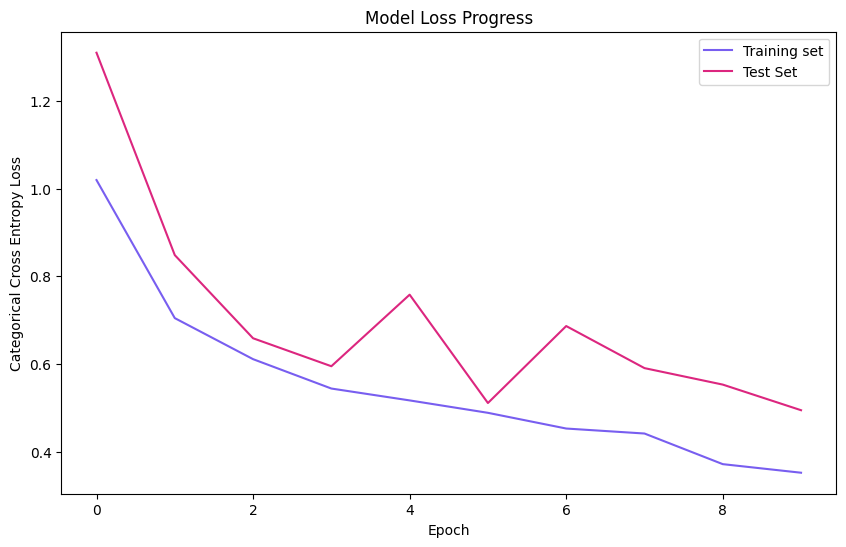

In [33]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,6))
plt.plot(hist.history['loss'], color='#785ef0')
plt.plot(hist.history['val_loss'], color='#dc267f')
plt.title('Model Loss Progress')
plt.ylabel('Categorical Cross Entropy Loss')
plt.xlabel('Epoch')
plt.legend(['Training set','Test Set'], loc='upper right')
plt.show()

In [34]:
# from tensorflow.keras.models import load_model

# classifier = load_model('ccn_model.h5')
# classifier = load_model('cnn.hdf5')

import os

# Load weights if the file exists
if os.path.exists('cnn1.weights.h5'):
    classifier.load_weights('cnn1.weights.h5')
    print("Weights loaded from cnn1.weights.h5")
elif os.path.exists('cnn.hdf5'):
    classifier.load_weights('cnn.hdf5')
    print("Weights loaded from cnn.hdf5")
else:
    print("Warning: No weight file found. Using current model weights from training.")

classifier.compile(optimizer=RMSprop(), loss='categorical_crossentropy', metrics=['accuracy'])

Weights loaded from cnn1.weights.h5


In [35]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt
import numpy as np
(_, _),(_, labels) = fashion_mnist.load_data()
y_ = labels
y_hat = classifier.predict(x_test)
y_pred = np.argmax(y_hat, axis=1)

print(classification_report(np.argmax(y_test,axis=1), np.argmax(y_hat, axis=1), labels=[0,1,2,3,4,5,6,7,8,9]))

cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(y_hat, axis=1), labels=[0,1,2,3,4,5,6,7,8,9])
print(cm)

ber = 1-balanced_accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hat, axis=1))
print('BER', ber)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.87      0.68      0.76      1000
           1       0.99      0.97      0.98      1000
           2       0.76      0.67      0.72      1000
           3       0.85      0.86      0.85      1000
           4       0.65      0.84      0.74      1000
           5       0.97      0.95      0.96      1000
           6       0.58      0.60      0.59      1000
           7       0.93      0.92      0.92      1000
           8       0.96      0.96      0.96      1000
           9       0.92      0.96      0.94      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000

[[682   1  29  48   7   3 219   0  11   0]
 [  0 967   1  24   2   0   4   0   2   0]
 [  4   2 673  11 221   0  83   0   6   0]
 [ 15   4  11 861  51   0  56   0   2   0]
 [  1   0  52  38 843   0  6

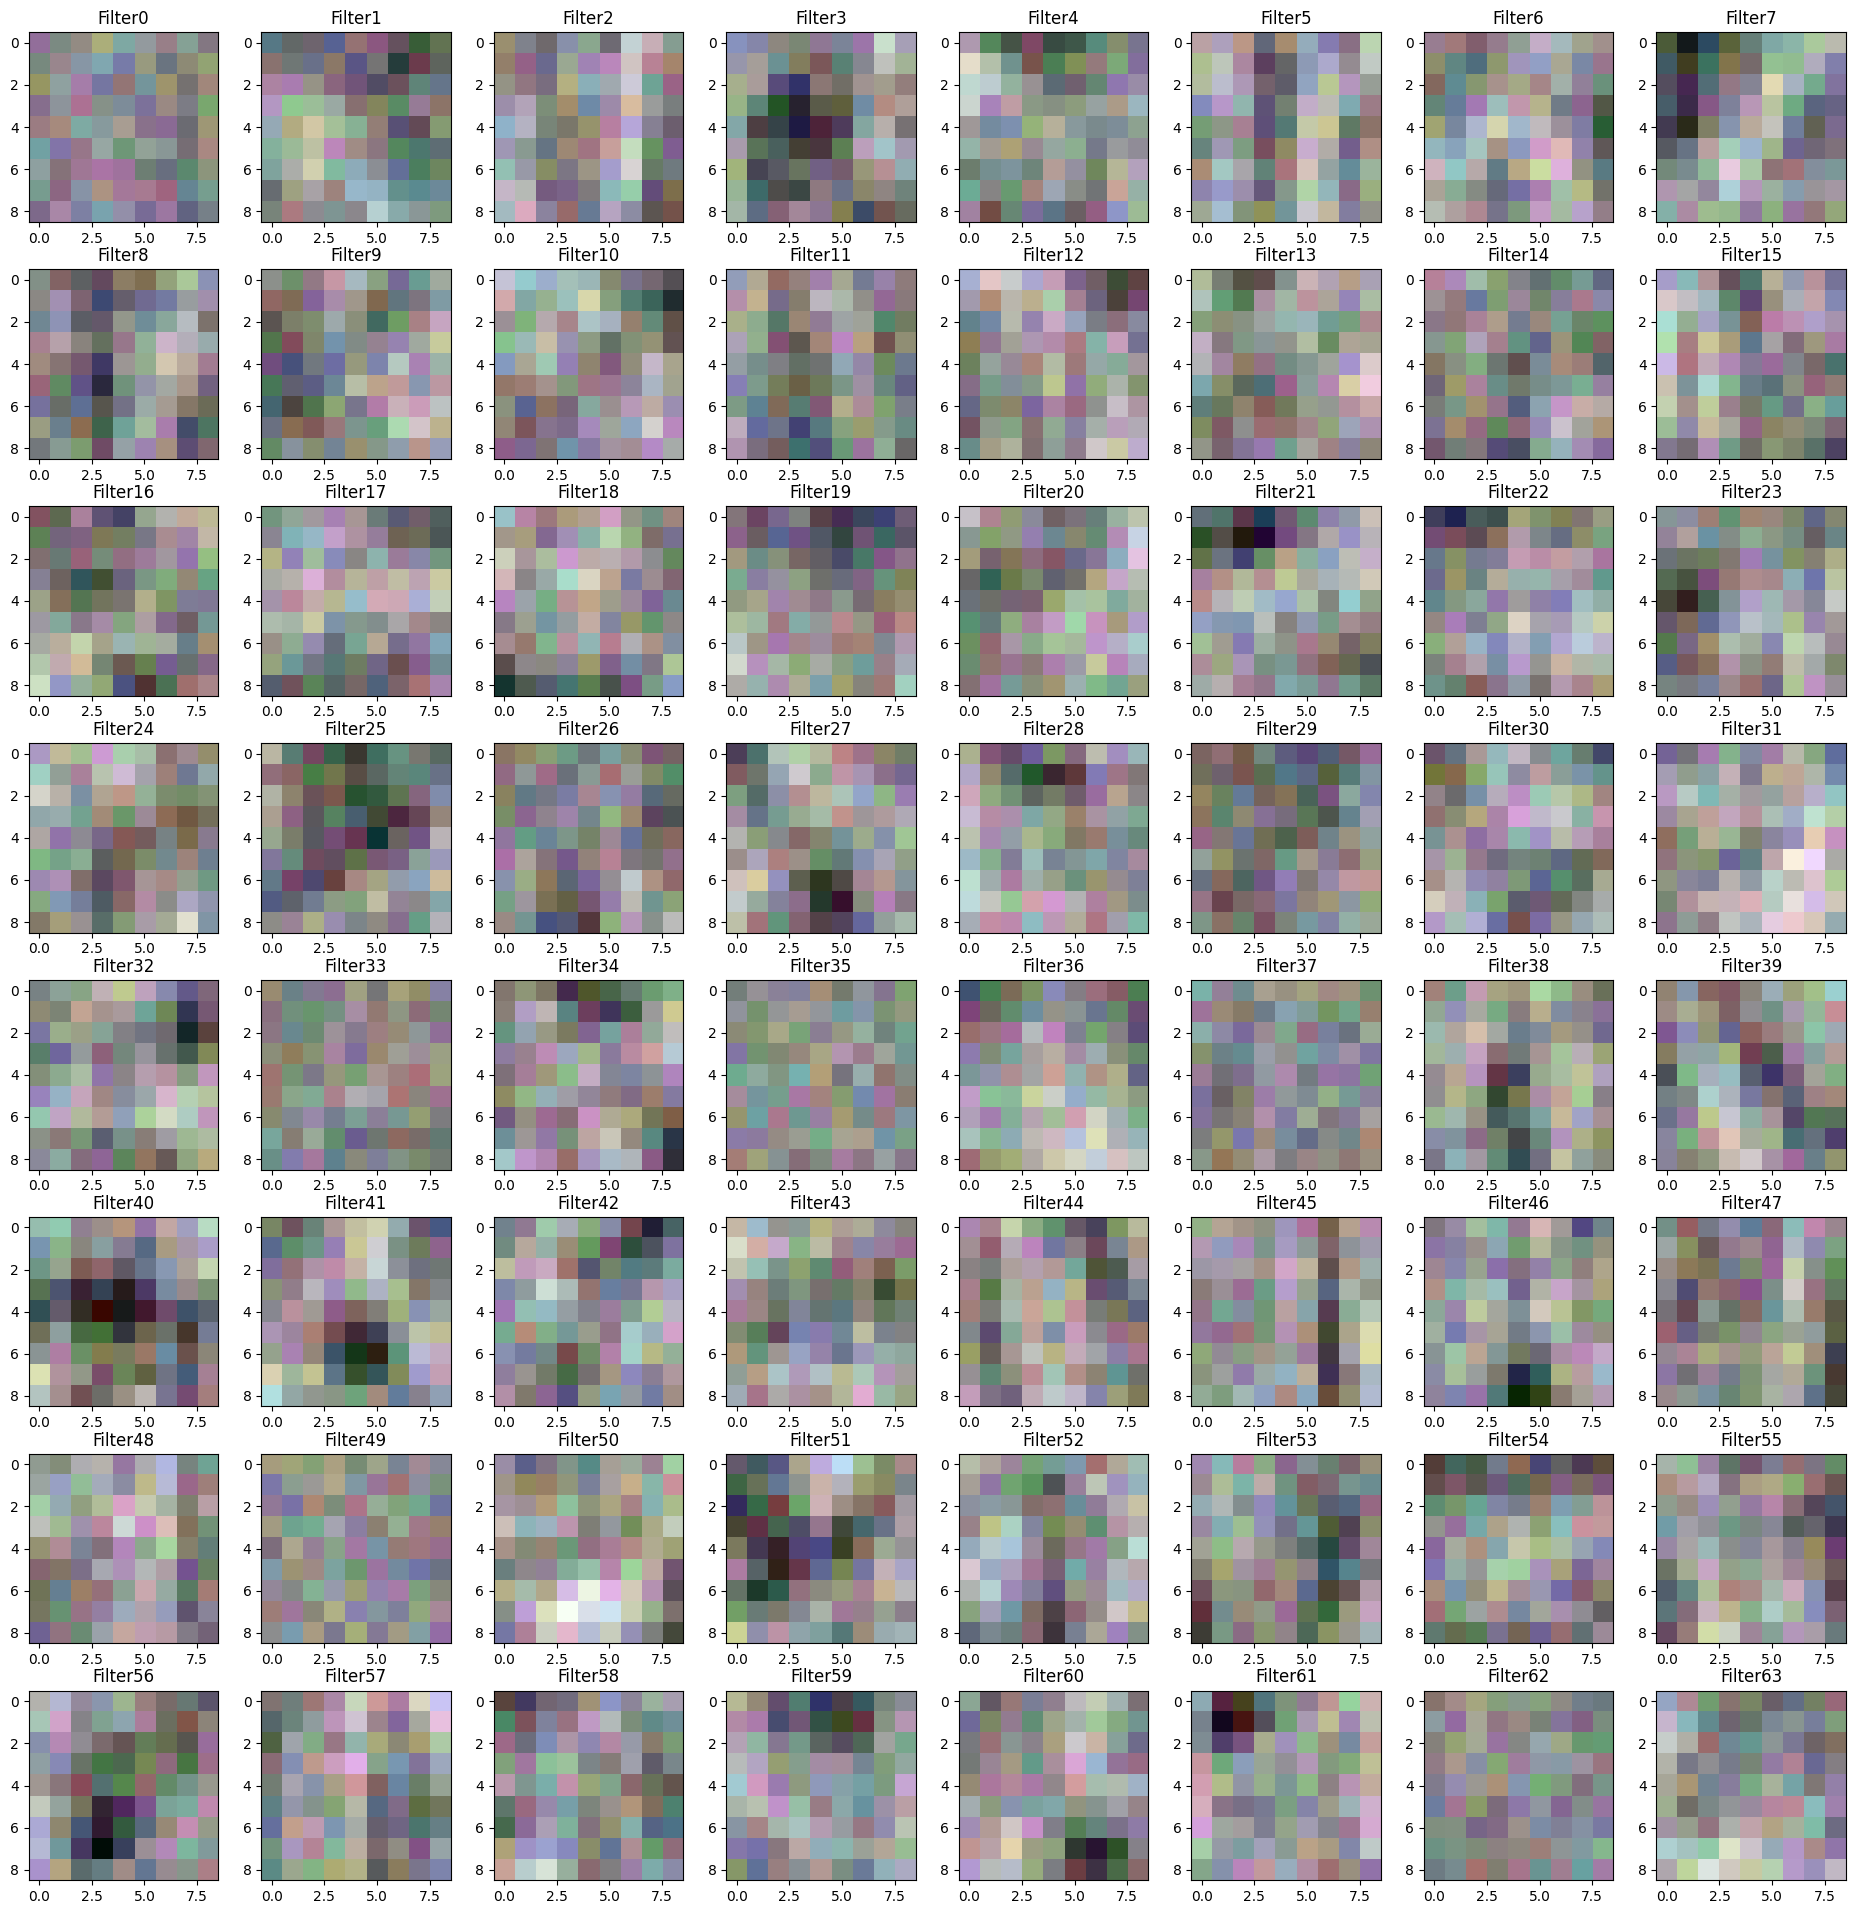

In [36]:
from sklearn.preprocessing import MinMaxScaler
cnn11 = classifier.layers[1].name # get the name of the 1st convolutional layer
w =classifier.get_layer(name=cnn11).get_weights()[0] # get the filters
wshape = w.shape # save the original shape
# we will scale to [0,1] for visualization purposes
scaler = MinMaxScaler()
scaler.fit(w.reshape(-1,1))
w = scaler.transform(w.reshape(-1,1))
w = w.reshape(wshape)
# we will display them 8x8
fig,axs = plt.subplots(8,8,figsize=(24,24))
fig.subplots_adjust(hspace=.25, wspace=.001)
axs = axs.ravel()
for i in range(w.shape[-1]):
  #we will reshape to a 3D (RGB) image shape and display
  h=np.reshape(w[:,:,:,i],(9,9,3))
  axs[i].imshow(h)
  axs[i].set_title('Filter'+str(i))

Gabor filters